# Model Training

## Library Import

### Basic Import

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Modelling

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
#from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV


In [22]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

## Import the CSV Data as Pandas DataFrame

In [3]:
df=pd.read_csv('data.csv')

## Show 5 records

In [12]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Preparing X and Y variables

In [14]:
X=df.drop(columns=['math_score'],axis=1)
y=df['math_score']

In [15]:
X.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


### Create Column Transformer with 3 types of transformer

In [17]:
num_features=X.select_dtypes(exclude=['object']).columns
cat_features=X.select_dtypes(include=['object']).columns

In [18]:
numeric_transformer= StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor= ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ]
)

In [19]:
X=preprocessor.fit_transform(X)

In [20]:
X.shape

(1000, 19)

### Seperate Dataset Into Train And Test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

## Create an Evaluate Function to give all metrics after model training

In [24]:
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2=r2_score(true,predicted)
    return mae,mse,rmse,r2

## Model Training

In [28]:
models={
    'Linear Regression':LinearRegression(),
    'Ridge Regression':Ridge(),
    'Lasso Regression':Lasso(),
    'Decision Tree':DecisionTreeRegressor(),
    'Random Forest':RandomForestRegressor(),
    'KNeighbors':KNeighborsRegressor(),
    'AdaBoost':AdaBoostRegressor(),
    'Support Vector Machine':SVR(),
    'XGBoost':XGBRegressor(),
    'LightGBM':LGBMRegressor()
}

model_list=[]
r2_list=[]
keys=list(models.keys())
values=list(models.values())
for i in range(len(models)):
    model_name=keys[i]
    model=values[i]
    model.fit(X_train,y_train)

    #Make Predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    #Evaluate Train and Test dataset
    mae_train, mse_train, rmse_train, r2_train = evaluate_model(y_train,y_train_pred)
    mae_test, mse_test, rmse_test, r2_test = evaluate_model(y_test,y_test_pred)

    print(keys[i])
    model_list.append(keys[i])

    print("Model performance for Train Set")
    print("-Root Mean Squared Error: {:.4f} ".format(rmse_train))
    print("-Mean Absolute Error: {:.4f} ".format(mae_train))
    print("-Mean Squared Error: {:.4f} ".format(mse_train))
    print("-R2 Score: {:.4f} ".format(r2_train))
    print("\n")

    print("Model performance for Test Set")
    print("-Root Mean Squared Error: {:.4f} ".format(rmse_test))
    print("-Mean Absolute Error: {:.4f} ".format(mae_test))
    print("-Mean Squared Error: {:.4f} ".format(mse_test))
    print("-R2 Score: {:.4f} ".format(r2_test))
    print("\n")
    r2_list.append(r2_test)

    print("="*50)
    print("\n")

Linear Regression
Model performance for Train Set
-Root Mean Squared Error: 5.3231 
-Mean Absolute Error: 4.2667 
-Mean Squared Error: 28.3349 
-R2 Score: 0.8743 


Model performance for Test Set
-Root Mean Squared Error: 5.3940 
-Mean Absolute Error: 4.2148 
-Mean Squared Error: 29.0952 
-R2 Score: 0.8804 




Ridge Regression
Model performance for Train Set
-Root Mean Squared Error: 5.3233 
-Mean Absolute Error: 4.2650 
-Mean Squared Error: 28.3378 
-R2 Score: 0.8743 


Model performance for Test Set
-Root Mean Squared Error: 5.3904 
-Mean Absolute Error: 4.2111 
-Mean Squared Error: 29.0563 
-R2 Score: 0.8806 




Lasso Regression
Model performance for Train Set
-Root Mean Squared Error: 6.5938 
-Mean Absolute Error: 5.2063 
-Mean Squared Error: 43.4784 
-R2 Score: 0.8071 


Model performance for Test Set
-Root Mean Squared Error: 6.5197 
-Mean Absolute Error: 5.1579 
-Mean Squared Error: 42.5064 
-R2 Score: 0.8253 




Decision Tree
Model performance for Train Set
-Root Mean Square

  File "e:\udemy\Data_Science\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "e:\udemy\Data_Science\venv\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\udemy\Data_Science\venv\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\udemy\Data_Science\venv\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


AdaBoost
Model performance for Train Set
-Root Mean Squared Error: 5.7907 
-Mean Absolute Error: 4.7410 
-Mean Squared Error: 33.5323 
-R2 Score: 0.8513 


Model performance for Test Set
-Root Mean Squared Error: 6.1366 
-Mean Absolute Error: 4.7605 
-Mean Squared Error: 37.6573 
-R2 Score: 0.8452 




Support Vector Machine
Model performance for Train Set
-Root Mean Squared Error: 6.5770 
-Mean Absolute Error: 4.8692 
-Mean Squared Error: 43.2570 
-R2 Score: 0.8081 


Model performance for Test Set
-Root Mean Squared Error: 8.1266 
-Mean Absolute Error: 5.4015 
-Mean Squared Error: 66.0420 
-R2 Score: 0.7286 




XGBoost
Model performance for Train Set
-Root Mean Squared Error: 1.0073 
-Mean Absolute Error: 0.6875 
-Mean Squared Error: 1.0146 
-R2 Score: 0.9955 


Model performance for Test Set
-Root Mean Squared Error: 6.4733 
-Mean Absolute Error: 5.0577 
-Mean Squared Error: 41.9037 
-R2 Score: 0.8278 




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of te

## Model Selection

In [29]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2 Score']).sort_values(by='R2 Score',ascending=False)

,Model,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
4,Random Forest,0.851701
6,AdaBoost,0.845247
9,LightGBM,0.841107
8,XGBoost,0.827797
2,Lasso Regression,0.825320
5,KNeighbors,0.783813
3,Decision Tree,0.742252
7,Support Vector Machine,0.728600


Ridge and Linear Regression almost same. So selecting Linear Regression

## Linear Regression

In [30]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("R2 Score: ",score)

R2 Score:  88.04332983749565


### Plot y_pred and y_test

Text(0, 0.5, 'Predicted Values')

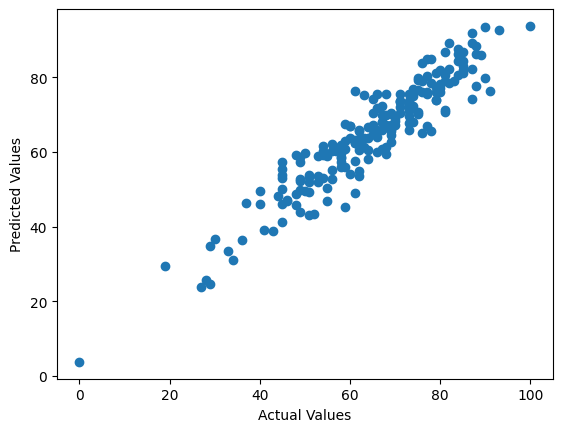

In [31]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

<Axes: xlabel='math_score'>

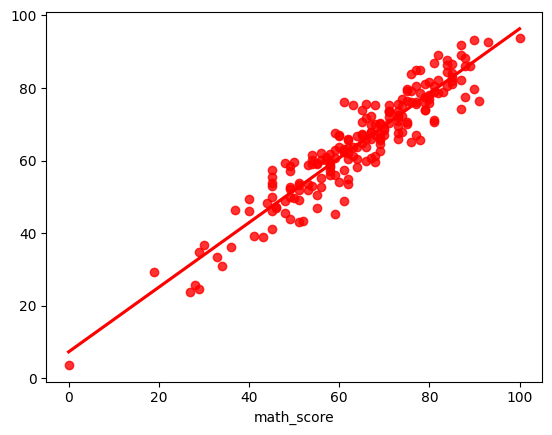

In [32]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

## Difference between Actual and Predicted Values

In [34]:
pred_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
